## Population Density Visualization

### Library import

In [ ]:
import osmnx as ox          # fetching city boundary polygons from OpenStreetMap
import rasterio             # reading and clipping GeoTIFF raster files
from rasterio.mask import mask  # clipping raster to a polygon boundary
import matplotlib.pyplot as plt  # building visualizations
import numpy as np          # numerical operations and NaN handling
import glob                 # auto-detecting .tif files in the project folder

TIFF files were manually downloaded from WorldPop (https://hub.worldpop.org) and placed in the local project folder before running this notebook

In [2]:
#Loading tiff files
tif_files = sorted(glob.glob("vnm_pd_*_1km.tif"))
print("Найдено файлов:", len(tif_files))
print(tif_files)

Найдено файлов: 4
['vnm_pd_2000_1km.tif', 'vnm_pd_2010_1km.tif', 'vnm_pd_2015_1km.tif', 'vnm_pd_2020_1km.tif']


## TIFF files upload & clipping

In [3]:
# Loading & clipping tiff files
def load_city_data(city_name):
    # Get city boundary polygon from OpenStreetMap
    city = ox.geocode_to_gdf(city_name)
    # Convert to WGS84 coordinate system (same as tiff files)
    city = city.to_crs("EPSG:4326")
    # Extract geometry for masking
    geometry = [city.geometry.values[0]]
    
    years_data = {}
    for filepath in tif_files:
        # Extract year from filename (e.g. vnm_pd_2000_1km.tif → "2000")
        year = filepath.split("_")[2]
        with rasterio.open(filepath) as src:
            # Clip raster to city boundary
            clipped, transform = mask(src, geometry, crop=True)
            # Convert to float for NaN support
            data = clipped[0].astype(float)
            # Replace nodata values with NaN
            data[data < 0] = np.nan
            years_data[year] = data
    
    print(f"{city_name} — loaded years: {list(years_data.keys())}")
    return years_data

## Graphs

**Note:** 

plot_city() is coded for exactly **4 years** (2x2 grid).

If you have a different number of files, update this line:

*fig, axes = plt.subplots(2, 2, figsize=(13, 10))*

**For example**, 6 years - plt.subplots(2, 3), 3 years - plt.subplots(1, 3)

In [4]:
# Vizualization
def plot_city(years_data, city_title):
    # Set color scale: min value and 95th percentile as max (to avoid outliers)
    vmin = min(np.nanmin(d) for d in years_data.values())
    vmax = max(np.nanpercentile(d, 95) for d in years_data.values())
    
    # Create 2x2 grid for 4 years
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    axes = axes.flatten()
    
    # Plot each year
    for i, (year, data) in enumerate(sorted(years_data.items())):
        im = axes[i].imshow(data, cmap="viridis", vmin=vmin, vmax=vmax)
        axes[i].set_title(f"{city_title} {year}", fontsize=14)
        axes[i].axis("off")
    
    # Add single shared colorbar on the right
    fig.subplots_adjust(right=0.85, top=0.92)
    cax = fig.add_axes([0.88, 0.25, 0.01, 0.5])
    cbar = fig.colorbar(im, cax=cax, label="people/km²")
    cbar.outline.set_visible(False)
    
    plt.suptitle("Population Density", fontsize=16, fontweight="bold")
    plt.show()

## City - Hanoi 

Hanoi, Vietnam — loaded years: ['2000', '2010', '2015', '2020']


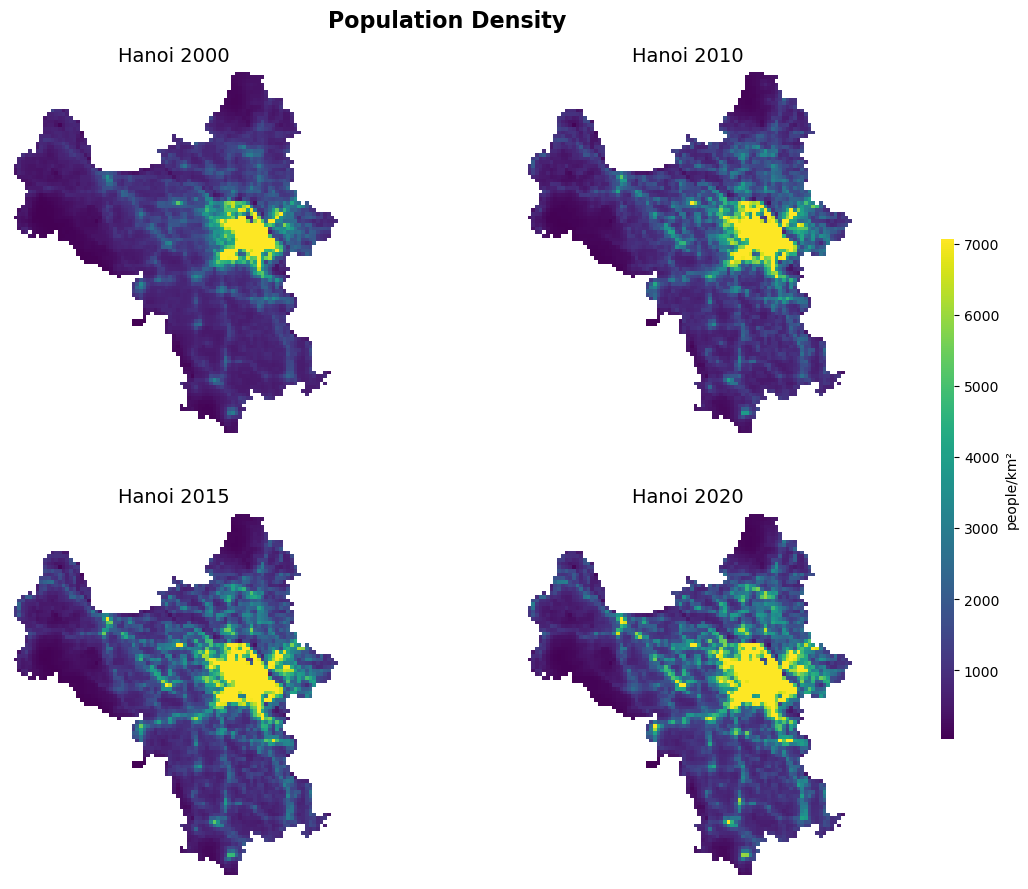

In [5]:
hanoi_data = load_city_data("Hanoi, Vietnam")
plot_city(hanoi_data, "Hanoi")

## City - Ho Chi Minh City

Ho Chi Minh City, Vietnam — loaded years: ['2000', '2010', '2015', '2020']


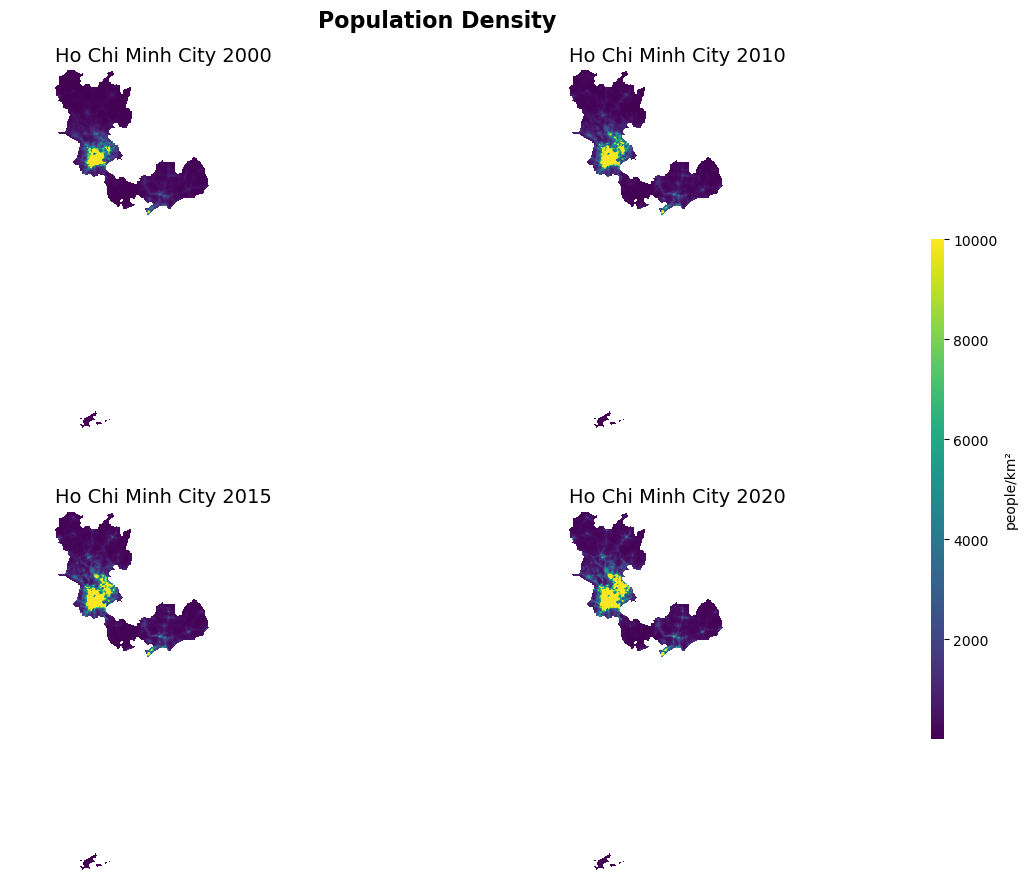

In [6]:
saigon_data = load_city_data("Ho Chi Minh City, Vietnam")
plot_city(saigon_data, "Ho Chi Minh City")

## City - Da Nang

Da Nang, Vietnam — loaded years: ['2000', '2010', '2015', '2020']


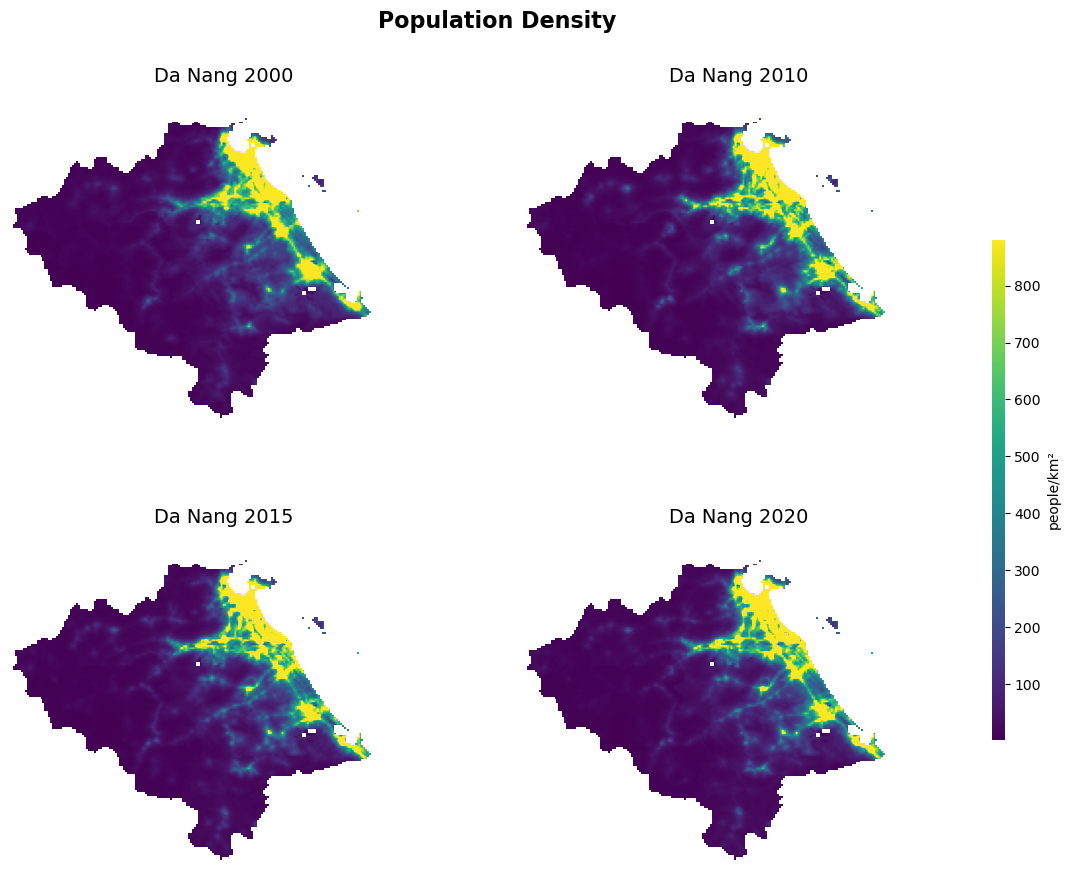

In [7]:
danang_data = load_city_data("Da Nang, Vietnam")
plot_city(danang_data, "Da Nang")

## City - Phu Quoc

Phu Quoc, Vietnam — loaded years: ['2000', '2010', '2015', '2020']


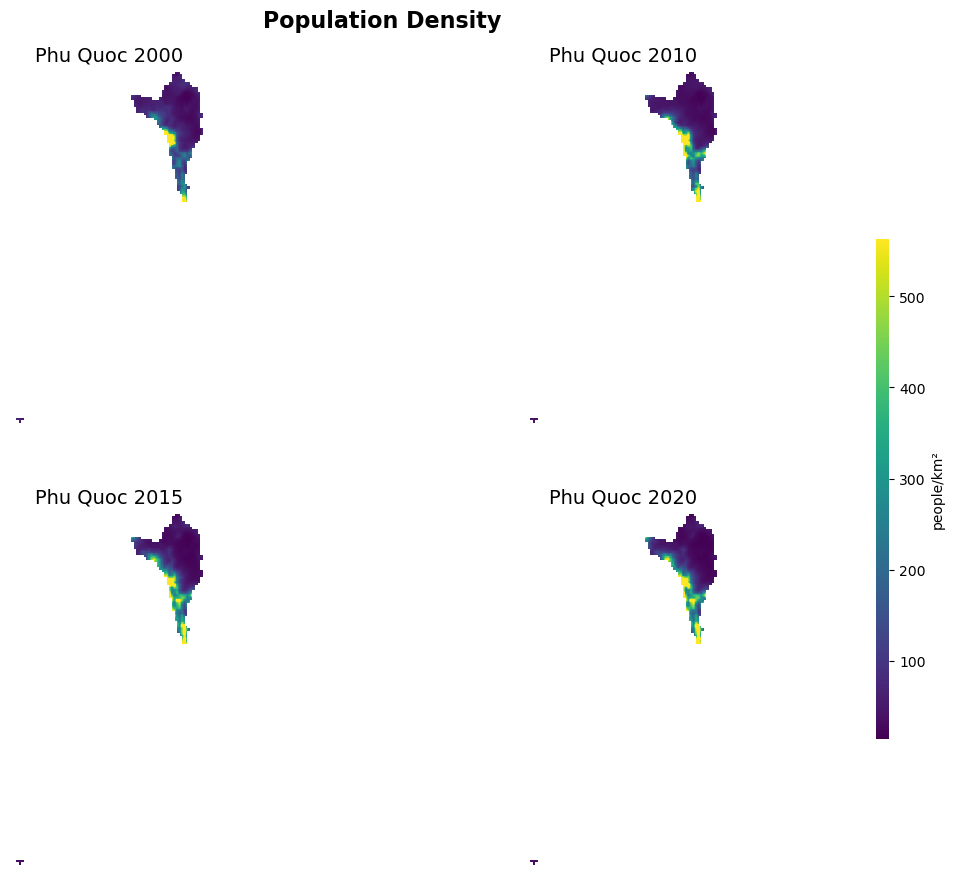

In [8]:
phuquoc_data = load_city_data("Phu Quoc, Vietnam")
plot_city(phuquoc_data, "Phu Quoc")